# Microsoft Stock Analysis Project


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("Microsoft_Stock.csv")
df.head()


,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


## 2. Data Loading and Preparation


In [3]:
import pandas as pd

df = pd.read_csv("Microsoft_Stock.csv", parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index("Date")
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-04-01 16:00:00,40.60,40.76,40.31,40.72,36865322
2015-04-02 16:00:00,40.66,40.74,40.12,40.29,37487476
2015-04-06 16:00:00,40.34,41.78,40.18,41.55,39223692
2015-04-07 16:00:00,41.61,41.91,41.31,41.53,28809375
2015-04-08 16:00:00,41.48,41.69,41.04,41.42,24753438


### 2.1 Data Quality Checks


In [4]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [5]:
df.describe()

,Open,High,Low,Close,Volume
count,1511.000000,1511.000000,1511.000000,1511.000000,1.511000e+03
mean,107.385976,108.437472,106.294533,107.422091,3.019863e+07
std,56.691333,57.382276,55.977155,56.702299,1.425266e+07
min,40.340000,40.740000,39.720000,40.290000,1.016120e+05
25%,57.860000,58.060000,57.420000,57.855000,2.136213e+07
50%,93.990000,95.100000,92.920000,93.860000,2.662962e+07
75%,139.440000,140.325000,137.825000,138.965000,3.431962e+07
max,245.030000,246.130000,242.920000,244.990000,1.352271e+08


In [6]:
df.median()

Open            93.99
High            95.10
Low             92.92
Close           93.86
Volume    26629615.00
dtype: float64

### 2.2 Lags and Rolling Stats


In [7]:
for x in [1, 2, 3, 6, 12]:
    df[f"lag_{x}"] = df['Close'].shift(x)

In [8]:
df["rolling_mean_3"] = df['Close'].rolling(window=3).mean()
df["rolling_std_3"] = df['Close'].rolling(window=3).std()
df["rolling_mean_12"] = df['Close'].rolling(window=12).mean()

df['month'] = df.index.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [9]:
df_ml = df.dropna()

In [10]:
X = df_ml.drop(['Close', 'month'], axis=1)
y = df_ml['Close']

In [11]:
split = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

## 3. Exploratory Time-Series Analysis


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8040\867245384.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df["Close"].resample("M").mean()


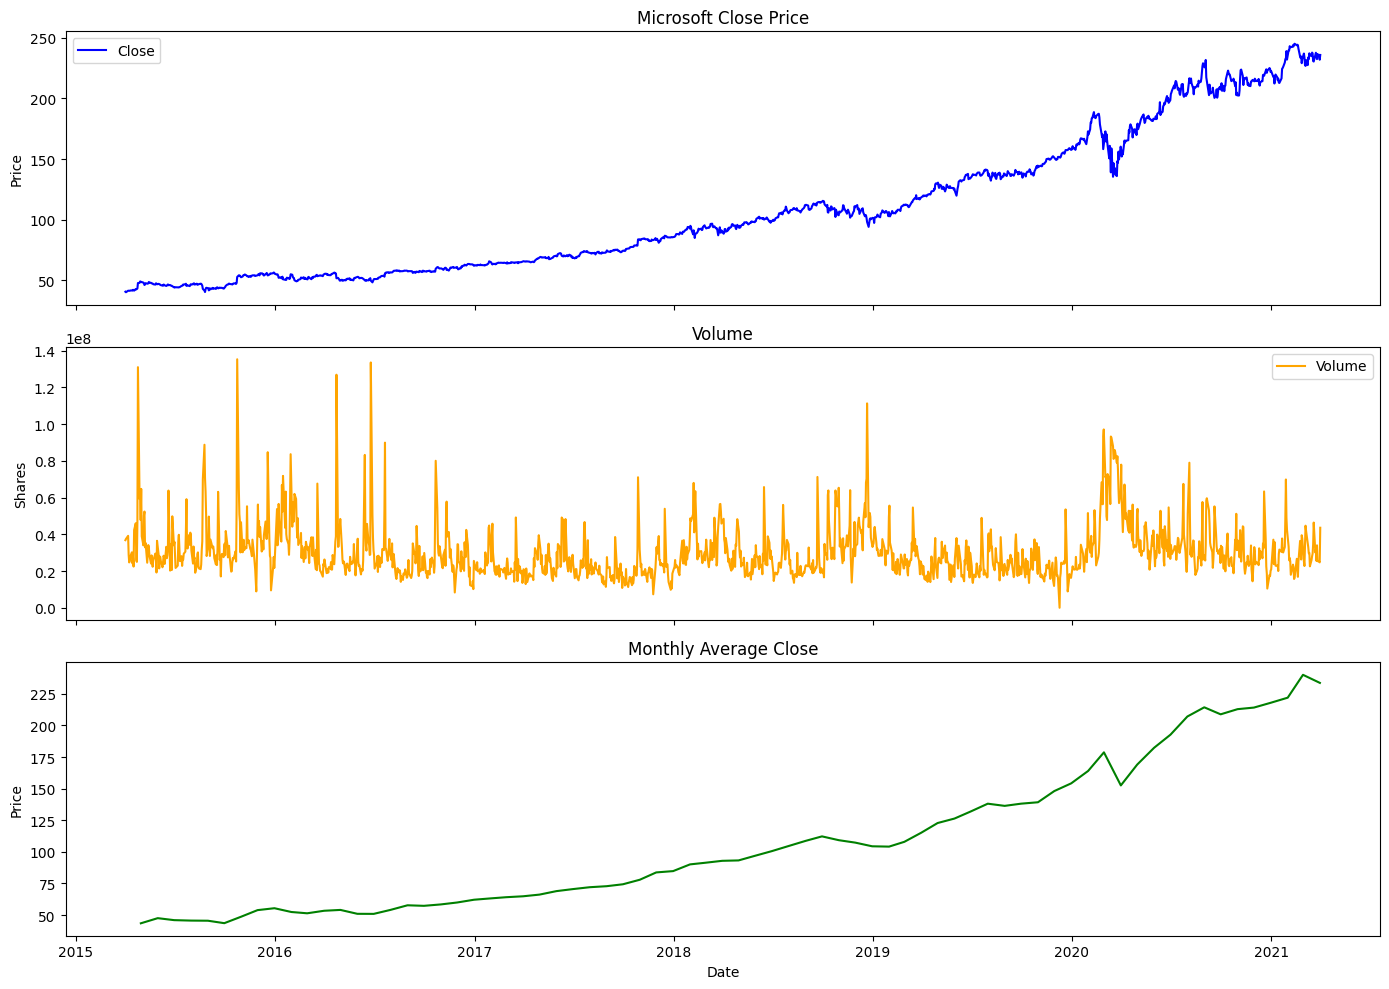

In [12]:
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax[0].plot(df.index, df["Close"], label="Close", color="blue")
ax[0].set_title("Microsoft Close Price")
ax[0].set_ylabel("Price")
ax[0].legend()

ax[1].plot(df.index, df["Volume"], label="Volume", color="orange")
ax[1].set_title("Volume")
ax[1].set_ylabel("Shares")
ax[1].legend()

monthly_close = df["Close"].resample("M").mean()
ax[2].plot(monthly_close.index, monthly_close.values, color="green")
ax[2].set_title("Monthly Average Close")
ax[2].set_ylabel("Price")
ax[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


### 3.1 Seasonal Decomposition


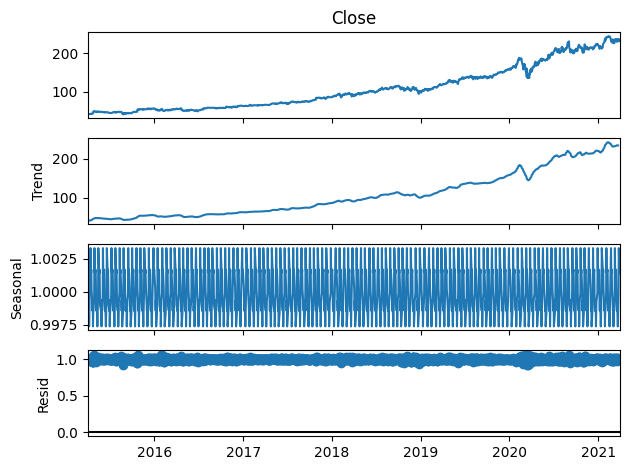

In [13]:
decomp = seasonal_decompose(df["Close"], model="multiplicative", period=12)
decomp.plot()
plt.tight_layout()
plt.show()

### 3.2 Stationarity Check and Differencing

In [14]:
def stationarity_tests(series, name="series"):
    s = series.dropna()
    adf_p = adfuller(s)[1]
    kpss_p = kpss(s, regression="c", nlags="auto")[1]
    print(f"{name}: ADF p={adf_p:.4f} (stationary if <0.05), KPSS p={kpss_p:.4f} (stationary if >0.05)")

stationarity_tests(df["Close"], "Original")

Original: ADF p=0.9982 (stationary if <0.05), KPSS p=0.0100 (stationary if >0.05)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8040\778846592.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8040\778846592.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_8040\778846592.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]


Log: ADF p=0.9465 (stationary if <0.05), KPSS p=0.0100 (stationary if >0.05)
Log diff(1): ADF p=0.0000 (stationary if <0.05), KPSS p=0.1000 (stationary if >0.05)
Log diff(12)+diff(1): ADF p=0.0000 (stationary if <0.05), KPSS p=0.1000 (stationary if >0.05)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8040\778846592.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]


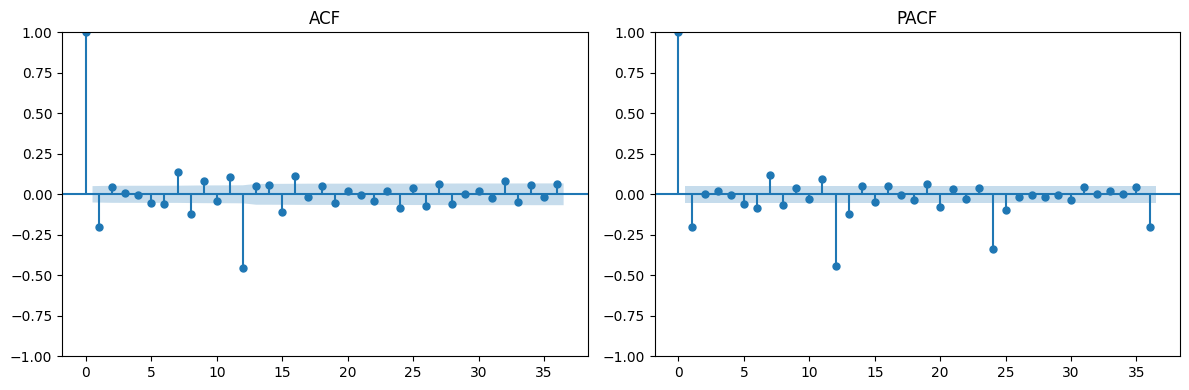

In [15]:
# Transform + differencing + ACF/PACF
df["log_close"] = np.log(df["Close"])
df["log_diff_1"] = df["log_close"].diff(1)
df["log_diff_12"] = df["log_close"].diff(12)
df["log_diff_12_1"] = df["log_diff_12"].diff(1)

stationarity_tests(df["log_close"], "Log")
stationarity_tests(df["log_diff_1"], "Log diff(1)")
stationarity_tests(df["log_diff_12_1"], "Log diff(12)+diff(1)")

fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(df["log_diff_12_1"].dropna(), lags=36, ax=axes[0])
plot_pacf(df["log_diff_12_1"].dropna(), lags=36, ax=axes[1], method="ywm")
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()


## 4. Classical Time-Series Methods

In [16]:
# Train/test split + baseline + ARIMA
test_size = 60  # last 60 trading days
train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

# Naive baseline
naive_pred = pd.Series(train["Close"].iloc[-1], index=test.index)

# ARIMA via SARIMAX (non-seasonal minimum model)
model = SARIMAX(
    train["log_close"],
    order=(1,1,1),
    seasonal_order=(0,0,0,0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_log = model.get_forecast(steps=len(test)).predicted_mean
arima_pred = np.exp(pred_log)

# SARIMA (weekly seasonality for trading days)
sarima_model = SARIMAX(
    train["log_close"],
    order=(1,1,1),
    seasonal_order=(1,1,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_pred_log = sarima_model.get_forecast(steps=len(test)).predicted_mean
sarima_pred = np.exp(sarima_pred_log)

# SARIMAX with exogenous variables
exog_cols = ["Open", "High", "Low", "Volume"]
train_exog = train[exog_cols]
test_exog = test[exog_cols]

sarimax_model = SARIMAX(
    train["log_close"],
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarimax_pred_log = sarimax_model.get_forecast(steps=len(test), exog=test_exog).predicted_mean
sarimax_pred = np.exp(sarimax_pred_log)

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next

Naive   -> MAE: 15.2607 RMSE: 17.108
ARIMA   -> MAE: 14.6386 RMSE: 16.3869
SARIMA  -> MAE: 7.4734 RMSE: 9.6478
SARIMAX -> MAE: 15.5136 RMSE: 17.2193


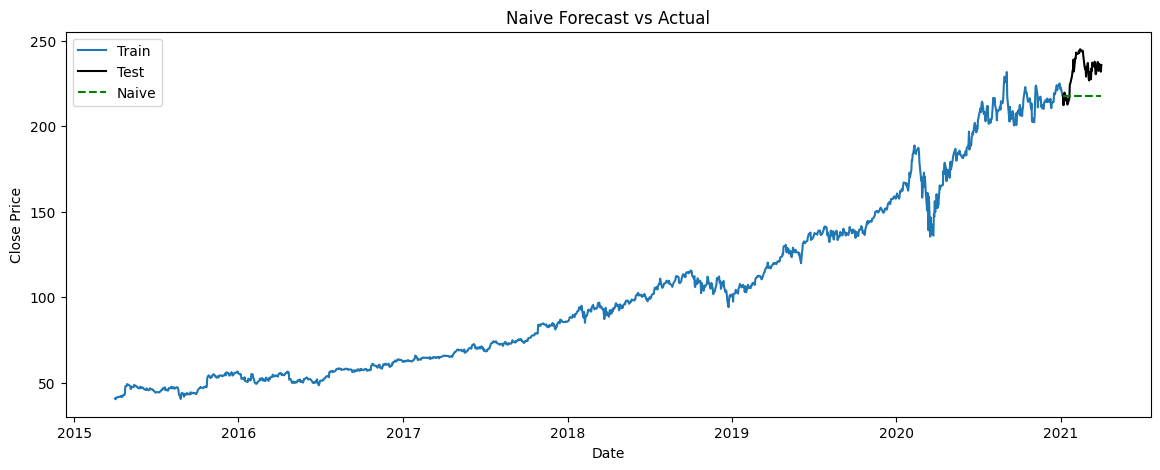

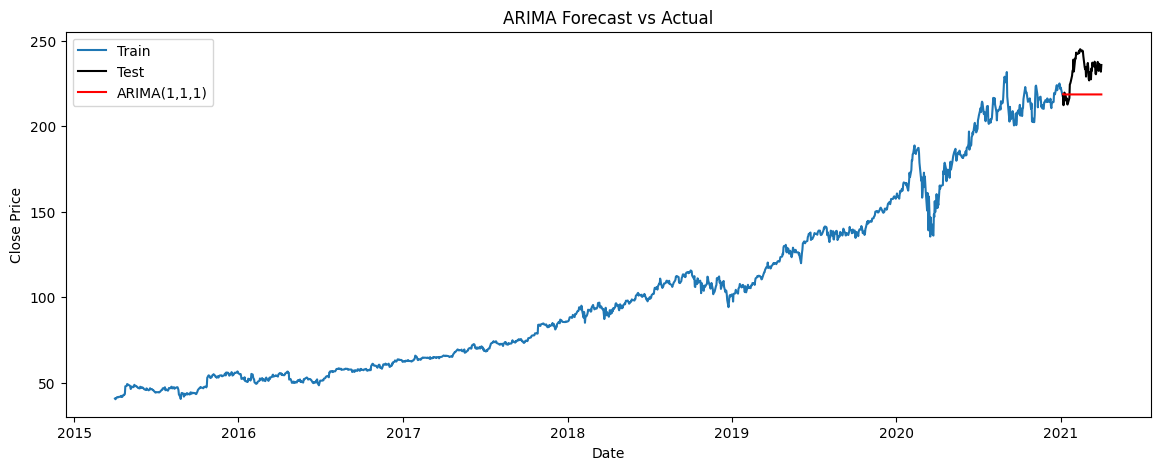

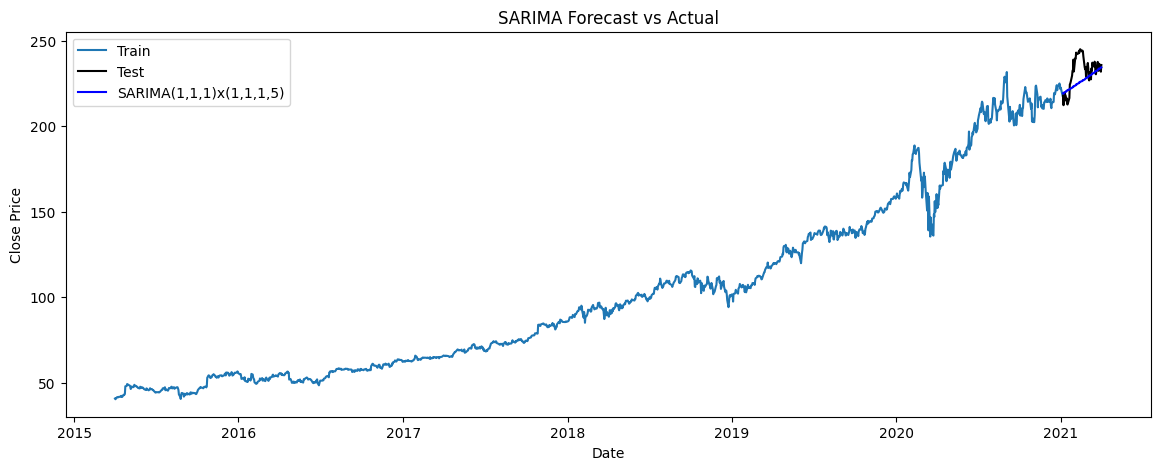

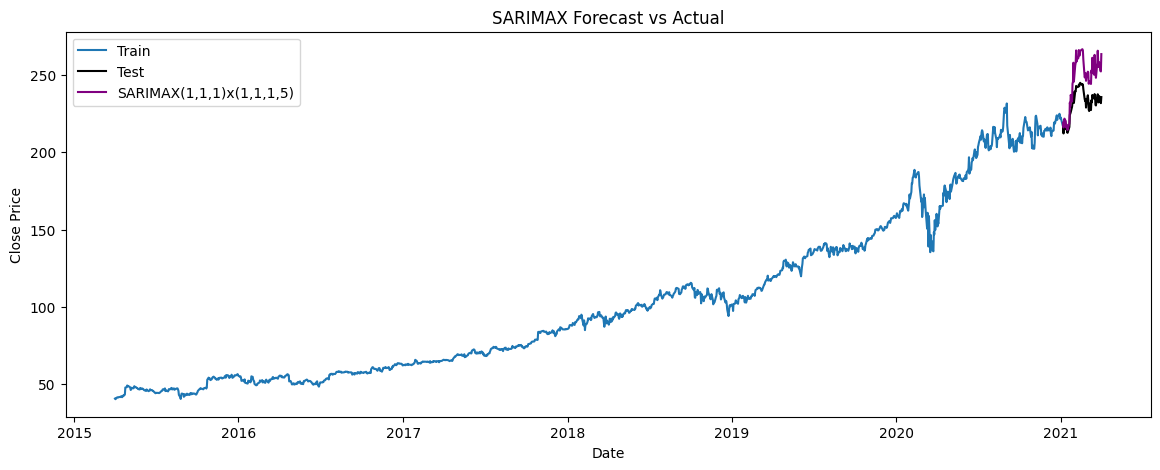

In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Naive   -> MAE:", round(mean_absolute_error(test["Close"], naive_pred), 4),
      "RMSE:", round(rmse(test["Close"], naive_pred), 4))
print("ARIMA   -> MAE:", round(mean_absolute_error(test["Close"], arima_pred), 4),
      "RMSE:", round(rmse(test["Close"], arima_pred), 4))
print("SARIMA  -> MAE:", round(mean_absolute_error(test["Close"], sarima_pred), 4),
      "RMSE:", round(rmse(test["Close"], sarima_pred), 4))
print("SARIMAX -> MAE:", round(mean_absolute_error(test["Close"], sarimax_pred), 4),
      "RMSE:", round(rmse(test["Close"], sarimax_pred), 4))

# Naive forecast plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train["Close"], label="Train")
plt.plot(test.index, test["Close"], label="Test", color="black")
plt.plot(test.index, naive_pred, label="Naive", linestyle="--", color="green")
plt.title("Naive Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# ARIMA forecast plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train["Close"], label="Train")
plt.plot(test.index, test["Close"], label="Test", color="black")
plt.plot(test.index, arima_pred, label="ARIMA(1,1,1)", color="red")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# SARIMA forecast plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train["Close"], label="Train")
plt.plot(test.index, test["Close"], label="Test", color="black")
plt.plot(test.index, sarima_pred, label="SARIMA(1,1,1)x(1,1,1,5)", color="blue")
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# SARIMAX forecast plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train["Close"], label="Train")
plt.plot(test.index, test["Close"], label="Test", color="black")
plt.plot(test.index, sarimax_pred, label="SARIMAX(1,1,1)x(1,1,1,5)", color="purple")
plt.title("SARIMAX Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


## 5. Machine Learning Models

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

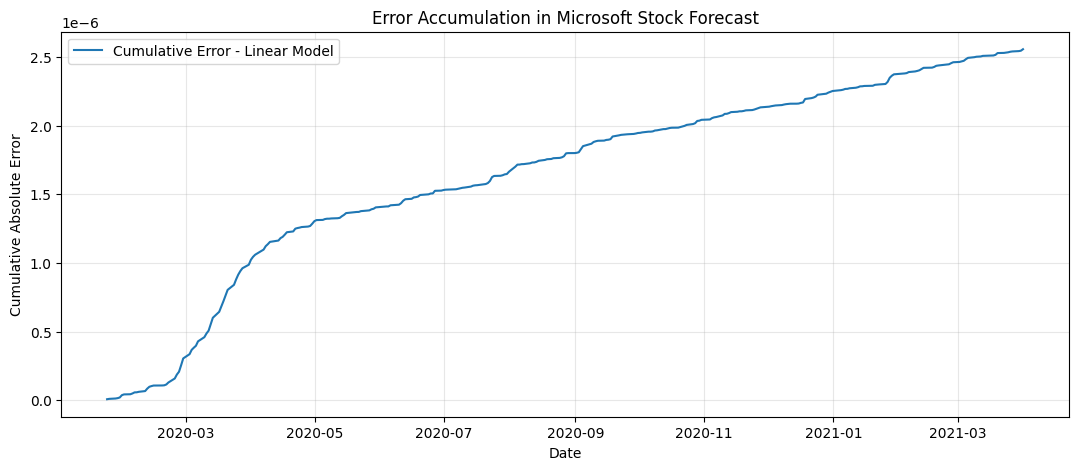

In [20]:
cum_err = np.abs(y_test.values - predictions).cumsum()

plt.figure(figsize=(13, 5))
plt.plot(y_test.index, cum_err, label='Cumulative Error - Linear Model')
plt.title('Error Accumulation in Microsoft Stock Forecast')
plt.xlabel('Date')
plt.ylabel('Cumulative Absolute Error')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
models = {
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(n_estimators=100),
    "XGBoost": XGBRegressor()
}

In [22]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = model.predict(X_test)

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.73076e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


### 5.1 Recursive Forecasting Utilities


In [23]:
def recursive_forecast(model, last_window, steps):
    forecasts = []
    current_window = last_window.copy()
    
    for _ in range(steps):
        pred = model.predict(current_window.reshape(1, -1))[0]
        forecasts.append(pred)
        
        current_window = np.roll(current_window, -1)
        current_window[-1] = pred
        
    return forecasts

In [24]:
last_known_data = X_test.iloc[-1].values
future_prices = recursive_forecast(models["XGBoost"], last_known_data, steps=7)

In [25]:
cum_err_df = pd.DataFrame({
    'Ridge Error': np.abs(y_test.values - results["Ridge"]).cumsum(),
    'RF Error': np.abs(y_test.values - results["RandomForest"]).cumsum(),
    'XGB Error': np.abs(y_test.values - results["XGBoost"]).cumsum(),
}, index=y_test.index)

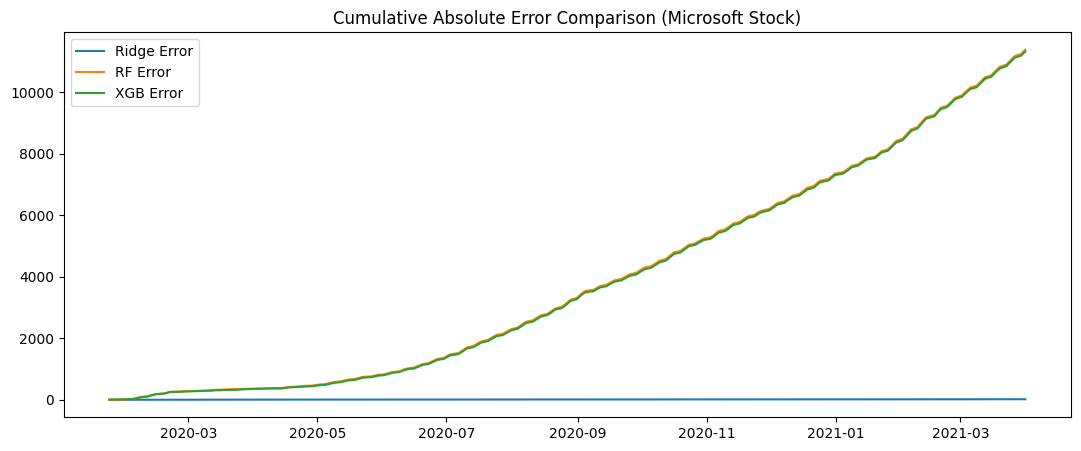

In [26]:
plt.figure(figsize=(13, 5))
for col in cum_err_df.columns:
    plt.plot(cum_err_df.index, cum_err_df[col], label=col)
plt.title('Cumulative Absolute Error Comparison (Microsoft Stock)')
plt.legend()
plt.show()

### 5.2 XGBoost Hyperparameter Tuning (TimeSeriesSplit)
Tune one model with time-series-aware CV, then evaluate on the held-out test set.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from itertools import product

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'reg_alpha': [0, 0.1, 1]
}

tscv = TimeSeriesSplit(n_splits=5)
best_mae = float('inf')
best_params = None

for n_estimators, max_depth, learning_rate, reg_alpha in product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['reg_alpha']
): 
    fold_maes = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            reg_alpha=reg_alpha
        )
        model.fit(X_tr, y_tr)
        val_pred = model.predict(X_val)
        fold_maes.append(mean_absolute_error(y_val, val_pred))

    cv_mae = np.mean(fold_maes)
    if cv_mae < best_mae:
        best_mae = cv_mae
        best_params = {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'learning_rate': learning_rate,
            'reg_alpha': reg_alpha
        }

best_xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params
)
best_xgb.fit(X_train, y_train)
best_xgb_pred = best_xgb.predict(X_test)

print('Best Params:', best_params)
print('CV MAE:', round(best_mae, 4))
print('Test MAE:', round(mean_absolute_error(y_test, best_xgb_pred), 4))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, best_xgb_pred)), 4))


Best Params: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05, 'reg_alpha': 0}
CV MAE: 9.9266
Test MAE: 37.8794
Test RMSE: 44.0464


### 5.3 Model Selection and 24-Step Forecasting


In [28]:
def generate_forecast(model, last_window, steps=24):
    forecasts = []
    current_features = last_window.copy()
    
    for _ in range(steps):
        pred = model.predict(current_features.reshape(1, -1))[0]
        forecasts.append(pred)
        current_features = np.roll(current_features, -1)
        current_features[-1] = pred
        
    return forecasts

In [29]:
models = {
    "Linear": [Ridge(), Lasso(), ElasticNet()],
    "Tree": [RandomForestRegressor(), ExtraTreesRegressor()],
    "Boosting": [XGBRegressor()]
}

In [30]:
best_models = {}
for category, model_list in models.items():
    best_mae = float('inf')
    for model in model_list:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        if mae < best_mae:
            best_mae = mae
            best_models[category] = model

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.73076e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.275e+02, tolerance: 1.266e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.945e+02, tolerance: 1.266e+02
  model = cd_fast.enet_coordinate_descent(


In [31]:
steps = 24
last_train_row = X_train.iloc[-1].values

best_tree_model = best_models['Tree']

tree_forecast = generate_forecast(best_tree_model, last_train_row, steps)
xgb_optimal_forecast = generate_forecast(best_xgb, last_train_row, steps)


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\util

In [32]:
cum_err_df = pd.DataFrame({
    'Tree Error': np.abs(y_test.values[:steps] - tree_forecast).cumsum(),
    'XGBoost Optimal Error': np.abs(y_test.values[:steps] - xgb_optimal_forecast).cumsum(),
}, index=y_test.index[:steps])


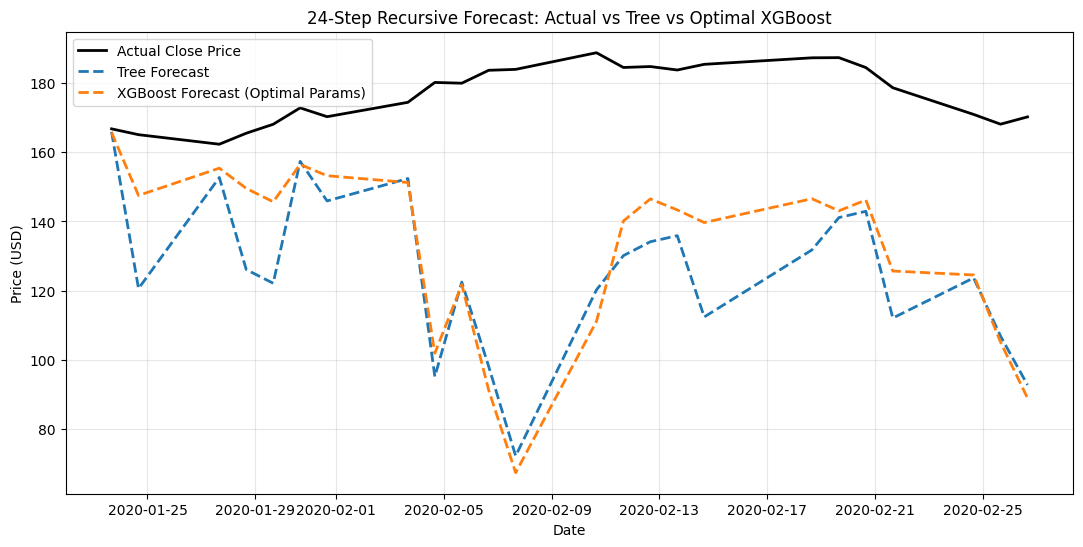

In [33]:
forecast_index = y_test.index[:steps]

plt.figure(figsize=(13, 6))
plt.plot(forecast_index, y_test.values[:steps], label='Actual Close Price', color='black', linewidth=2)
plt.plot(forecast_index, tree_forecast, label='Tree Forecast', linestyle='--', linewidth=2)
plt.plot(forecast_index, xgb_optimal_forecast, label='XGBoost Forecast (Optimal Params)', linestyle='--', linewidth=2)

plt.title('24-Step Recursive Forecast: Actual vs Tree vs Optimal XGBoost')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 5.4 Cumulative Error Comparison


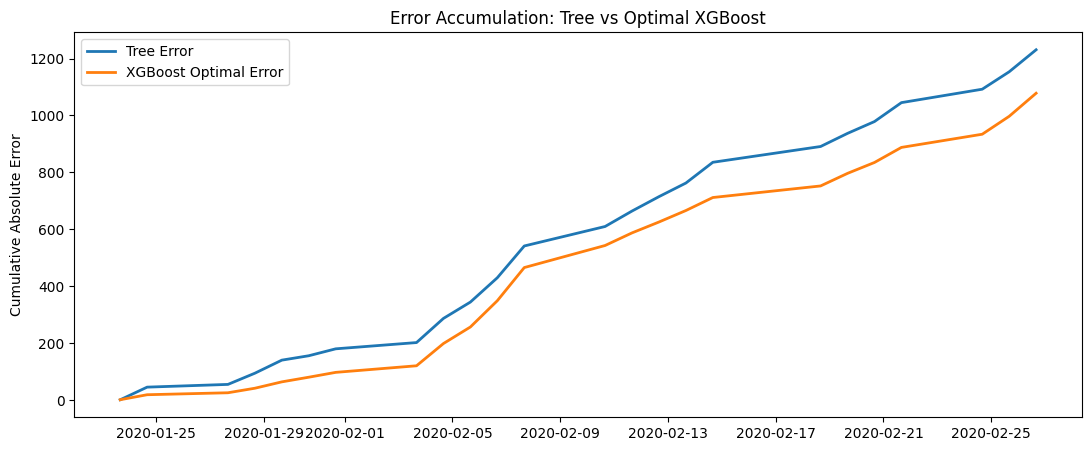

In [34]:
cum_err_df = pd.DataFrame({
    'Tree Error': np.abs(y_test.values[:steps] - tree_forecast).cumsum(),
    'XGBoost Optimal Error': np.abs(y_test.values[:steps] - xgb_optimal_forecast).cumsum(),
}, index=forecast_index)

plt.figure(figsize=(13, 5))
for col in cum_err_df.columns:
    plt.plot(cum_err_df.index, cum_err_df[col], linewidth=2, label=col)

plt.title('Error Accumulation: Tree vs Optimal XGBoost')
plt.ylabel('Cumulative Absolute Error')
plt.legend()
plt.show()
